# 23 · The impossible STARK, on the iGPU — RISC0 rv32im segment-STARK on `gfx1151` (hybrid, path-i)

**The headline.** The field said the RISC0 zkVM STARK is **CPU-only on AMD** (official GPU support is CUDA + Metal only; the generated `eval_check` was flagged *"most likely intractable"*). This notebook shows the scoped frontier result that overturns it:

> **RISC0 zkVM _segment_-STARK now produces a _stock-verifier-accepted_ seal on the `gfx1151` iGPU (hybrid, path-i).**

A pinned **v2.3.2 research fork** runs the rv32im segment-STARK math + the 26k-LOC generated `eval_check` on the **Radeon 8060S iGPU** (`gfx1151`), delegates witgen + accum to the CPU over unified memory, and emits a seal that the **stock `cargo risczero verify`** accepts — **bit-for-bit == risc0's own `CpuHal`** (DualHal 15/15).

**Honesty is part of the headline** (this is a *scoped/hybrid* result — the scope travels with every claim):

- ✅ **SAY** — a GPU-produced rv32im **segment**-STARK seal, accepted by the **stock** verifier, **bit-for-bit == CpuHal** (DualHal 15/15); the 26k-LOC `eval_check` compiles native HIP and is bit-for-bit GPU==CPU. **Hybrid**: STARK math + eval_check on the iGPU; **witgen + accum CPU-delegated** over unified memory. Recursion (lift/join/succinct) and the Groth16 wrap's BN254 MSM/NTT now run on the iGPU too; recursion witness/prefix-products and Groth16 witness generation stay CPU-delegated.
- 🚫 **NEVER** — "the iGPU proves the whole zkVM" · "pure-GPU prover" · "beats a 5090" · drop the **stock `r0vm` (CPU-only) vs scoped v2.3.2 fork (hybrid)** distinction.
- **Speed = 5.46×** for this segment-STARK workload (flat ~5.3–5.5×; old ~6.6–6.8× includes a **1.25× local-vs-shipped codegen gap**). Recursion is 3.3–5.2× scoped; the complete Groth16 receipt is **0.973×** (GPU ~2.7% slower) because CPU witness generation + orchestration dominates. **Correctness is the hard guarantee; speed is layer-specific.**
- **Amdahl**: segment witgen + accum = **28.9%** → moving them to the GPU buys **≤1.41×**. Lab 24 shows the next bottleneck-forensics step.

**Hybrid live-or-replay.** Panel (a) builds `r0vm --features rocm` + proves + stock-verifies **live** on a Strix Halo (with `LAB_RUN_HEAVY=1`), and **replays** the committed artefacts under [`poc/risc0-rocm-prover/artefacts/`](../poc/risc0-rocm-prover/artefacts/) on any laptop — every number is pulled from those artefacts (+ [`reading-notes/path-i`](../reading-notes/path-i-risc0-rocm-stark.md)), never fabricated. `make lab-replay` runs this notebook headless with zero live proving.

In [1]:
import os

import labkit as lk

info = lk.capability_badge()   # read-only AMD probe — the same badge as every lab notebook


def heavy_enabled():
    # opt-in gate: only build the fork r0vm --features rocm + prove + verify when asked
    return os.environ.get("LAB_RUN_HEAVY", "") == "1"

✓,Zen5 CPU,AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S · 32 threads · 94 GB unified
✓,Radeon iGPU (ROCm),gfx=gfx1151 · backend=rocm
—,Vulkan,not detected
✓,XDNA2 NPU,"enumerated (research; accelerates AI model, not proofs)"


## Panel (a) · The GPU-produced seal is REAL — stock-verifier-accepted, not a CPU fallback

The heavy cell builds the fork `r0vm --features rocm`, proves the Demo B ~4-segment Cartesi-step session on the iGPU,
and runs the **stock** `cargo risczero verify` — or replays the committed
[`stage4-gate.md`](../poc/risc0-rocm-prover/artefacts/stage4-gate.md). The proof that the STARK actually ran on the
`gfx1151` is the audit's **differential fallback test**: on one audited session the `rocm` binary drives the iGPU to
**95% busy** (375/385 rocm-smi samples nonzero, 4 HipHal segment-prover markers), while the **non-rocm** binary on the
*identical* session leaves it at **0%** (156 samples / 178 s, 0 markers). The seal stock-verifies (`Receipt is valid!`)
and is the **same size as the golden CPU seal** (1,112,064 bytes) with the **journal region bit-identical**
(`pre_root ‖ mcycle=100 ‖ post_root`, matching `step.public.json`).

🔴 **Never state this as "the receipt file is byte-identical to the golden".** The seal body is **not**
byte-reproducible: the golden `step.proof.bin` and `step.rocm.proof.bin` differ in **971,857 of 1,112,064 bytes
(87.39%)** — only a 156-byte serialization header and the 385-byte journal tail match — and
[`z2-bringup-report.md`](https://github.com/iiyyll01lin/zkp-final/blob/main/workshop/futuremode-2026/z2-bringup-report.md) §3.3 measured **five runs producing five
*different* 1,112,064-byte files, all stock-verified** (same size, different bytes: expected, not a defect).
**`bit-for-bit` belongs to the HAL ops (DualHal 15/15) and `eval_check` — Panel (b) below — never to the receipt file.**

Both arms above come from that one audited run, which is what makes them comparable. The gate prove reports its own
separate rocm-smi capture (95% busy, 80/83 samples) with **no** non-rocm control, so it is printed below as a single
condition and never plotted against the audit's non-rocm arm.

[REPLAY] RISC0-rocm hybrid STARK  (LAB_FORCE_REPLAY set; using committed artefacts)
[REPLAY] source: poc/risc0-rocm-prover/artefacts/stage4-gate.md
[REPLAY] source: poc/risc0-rocm-prover/artefacts/engine-map-ledger.md
[replay] GPU-produced rv32im segment-STARK seal:
  stock `cargo risczero verify`  : Receipt is valid!
  receipt bytes                  : 1112064 (same SIZE as the golden CPU seal; journal bit-identical, seal bytes differ per run)
  audit differential test (ONE session, both arms -> the controlled A/B):
    rocm binary                  : 95% busy  (375/385 samples, 4 HipHal markers)
    same binary, no rocm         : 0% busy  (156 samples / 178 s, 0 markers)  <- real GPU path, not a CPU fallback
  gate prove, separate capture   : 95% busy  (80/83 samples)  <- single condition, NOT half of the A/B above


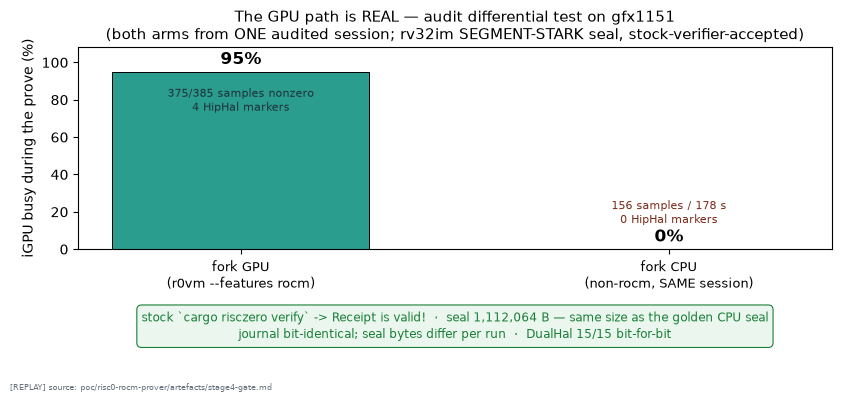

In [2]:
def live_seal():   # heavy: build fork r0vm --features rocm, prove Demo B step on the iGPU, stock-verify
    import subprocess
    script = lk.REPO_ROOT / "poc/risc0-rocm-prover/scripts/run-stage4-prove.sh"
    subprocess.run(["bash", str(script)], cwd=str(lk.REPO_ROOT), check=True)
    return lk.load_risc0_rocm_gate()    # same committed facts either way


def replay_seal():  # committed Stage-4 gate write-up — the source of truth
    return lk.load_risc0_rocm_gate()


gate, mode = lk.live_or_replay(
    live_seal, replay_seal,
    requires=[heavy_enabled, lk.has_rocm, lk.is_strix_halo],
    label="RISC0-rocm hybrid STARK")

fig = lk.plot_risc0_rocm_gpu_evidence(gate)

print(f"[{mode}] GPU-produced rv32im segment-STARK seal:")
print(f"  stock `cargo risczero verify`  : {'Receipt is valid!' if gate.get('verify_ok') else 'n/a'}")
print(f"  receipt bytes                  : {gate.get('receipt_bytes')} (same SIZE as the golden CPU seal;"
      " journal bit-identical, seal bytes differ per run)")
print("  audit differential test (ONE session, both arms -> the controlled A/B):")
print(f"    rocm binary                  : {gate.get('audit_gpu_busy_pct')}% busy  "
      f"({gate.get('audit_gpu_busy_samples')}/{gate.get('audit_gpu_total_samples')} samples, "
      f"{gate.get('audit_gpu_markers')} HipHal markers)")
print(f"    same binary, no rocm         : {gate.get('audit_nonrocm_busy_pct')}% busy  "
      f"({gate.get('audit_nonrocm_samples')} samples / {gate.get('audit_nonrocm_seconds')} s, "
      f"{gate.get('audit_nonrocm_markers')} markers)"
      f"  <- real GPU path, not a CPU fallback")
print(f"  gate prove, separate capture   : {gate.get('prove_gpu_busy_pct')}% busy  "
      f"({gate.get('prove_gpu_busy_samples')}/{gate.get('prove_gpu_total_samples')} samples)"
      f"  <- single condition, NOT half of the A/B above")

## Panel (b) · Correctness is the HARD guarantee — bit-for-bit GPU == risc0's own `CpuHal`

Every HAL op was gated **bit-for-bit against risc0's own `CpuHal` / CPU-C++ golden** before any timing — the same
discipline as the repo's `gpu-cpu-equality` gate. risc0's own **`DualHal`** harness (CpuHal vs HipHal) passes **15/15**,
and the flagged blocker — the **26k-LOC generated `eval_check`** — hipifies by swapping only the field backend (not one
line of generated code edited) and is **bit-for-bit GPU==CPU** (1024 checks). The bars below (log scale) are the
per-layer GPU==CPU equality-check counts from [`path-i`](../reading-notes/path-i-risc0-rocm-stark.md).

[REPLAY] source: reading-notes/path-i-risc0-rocm-stark.md
bit-for-bit GPU==CPU equality gates (from reading-notes/path-i):
  field    5632 checks PASS    (risc0_core BabyBear)
  hash     1768 + 400 PASS     (risc0_zkp hash suites)
  poly     38096 checks PASS   (the actual CpuHal ops)
  circuit  1024 checks PASS    (risc0 CPU C++ rust_poly_fp_*)
  Merkle   1984 checks PASS    (CpuHal)

  DualHal (risc0's OWN CpuHal-vs-HipHal harness): 15/15 PASS
  => the seal is a REAL STARK, and every op is bit-for-bit the same math the CpuHal computes.


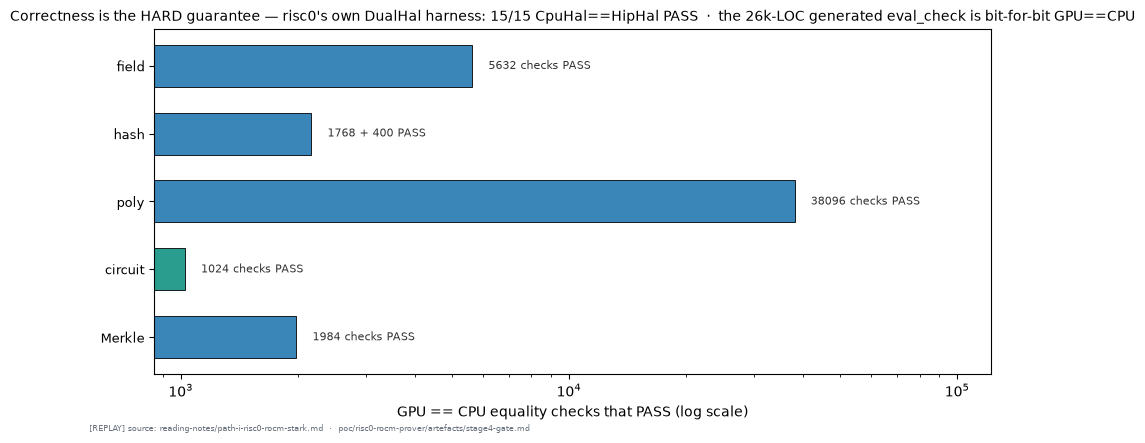

In [3]:
rows = lk.load_risc0_rocm_correctness()
fig = lk.plot_risc0_rocm_correctness(rows, gate)

print("bit-for-bit GPU==CPU equality gates (from reading-notes/path-i):")
for r in rows:
    print(f"  {r['layer']:<8} {r['gate']:<18}  ({r['golden']})")
print(f"\n  DualHal (risc0's OWN CpuHal-vs-HipHal harness): "
      f"{gate.get('dualhal_pass')}/{gate.get('dualhal_total')} PASS")
print("  => the seal is a REAL STARK, and every op is bit-for-bit the same math the CpuHal computes.")

## Panel (c) · The honest speed — 5.46× same-code, with the codegen-gap caveat

The **apples-to-apples** figure is **5.46×**: the fork built `--features rocm` (iGPU hybrid) vs the **same fork code**
built no-rocm on the same box (identical source + toolchain + generic codegen). The installed rzup `r0vm` is slower
still — that **1.25× local-vs-shipped codegen gap** is where the older "~6.6–6.8×" came from (`~6.8× = 5.46× × 1.25×`),
*not* CPU-baseline noise. It is **workload-specific** (poseidon2 is the only hashfn the rv32im prover accepts; hybrid
design), a flat ~5.3–5.5× across the po2 sweep — **not** a general "iGPU is faster" claim.

[REPLAY] source: poc/risc0-rocm-prover/artefacts/a3-speed.csv (3 rows)
same-code honest speed (a3-speed.csv; solo-guarded, every row stock-verifies):
   config             backend  wall_s  receipt_bytes verify  speedup_vs_fork_cpu
 fork-gpu r0vm-rocm-knowngood    26.1        1112064  valid             5.455939
 fork-cpu      r0vm-cpu-fresh   142.4        1112064  valid             1.000000
installed                r0vm   177.6        1112064  valid             0.801802

  headline    : 5.46x  (iGPU 26.1s vs same-code CPU 142.4s)
  codegen gap : 1.25x  (installed rzup 177.6s vs same-code fork-CPU 142.4s)
  => 5.46x is the honest same-code figure; the rest is codegen. Correctness is the hard guarantee.


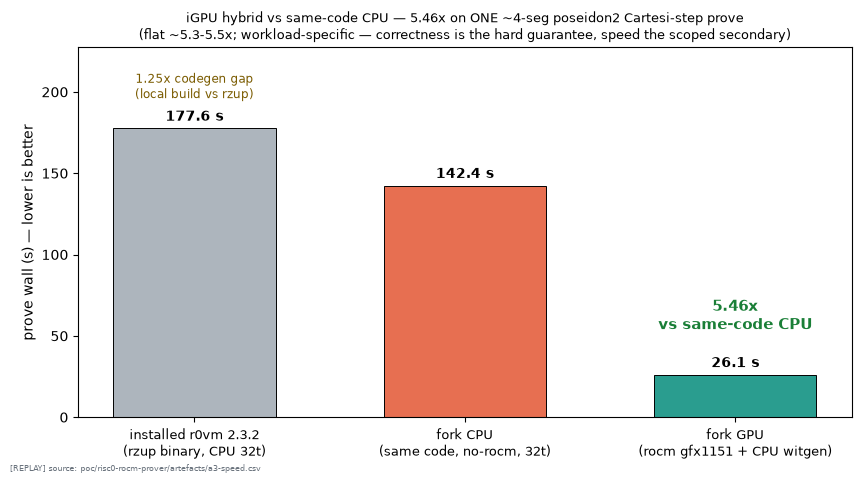

In [4]:
bench = lk.load_risc0_rocm_bench()
fig = lk.plot_risc0_rocm_bench(bench)

print("same-code honest speed (a3-speed.csv; solo-guarded, every row stock-verifies):")
print(bench[["config", "backend", "wall_s", "receipt_bytes", "verify",
             "speedup_vs_fork_cpu"]].to_string(index=False))
try:
    w = bench.set_index("config")["wall_s"]
    print(f"\n  headline    : {w['fork-cpu'] / w['fork-gpu']:.2f}x  "
          f"(iGPU {w['fork-gpu']:.1f}s vs same-code CPU {w['fork-cpu']:.1f}s)")
    print(f"  codegen gap : {w['installed'] / w['fork-cpu']:.2f}x  "
          f"(installed rzup {w['installed']:.1f}s vs same-code fork-CPU {w['fork-cpu']:.1f}s)")
    print("  => 5.46x is the honest same-code figure; the rest is codegen. Correctness is the hard guarantee.")
except Exception as exc:
    print(f"(speed summary skipped: {exc})")

## Panel (d) · Why hybrid is the sweet spot — phase breakdown + the Amdahl ceiling

Where does the prove wall actually go? Two independent instruments (CPU timers + `rocprofv3`) agree: **~59% of the
prove runs on the iGPU** (eval_check + NTT + Merkle), and the two **CPU-delegated** phases — **witgen + accum = 28.9%** —
are the only Part-B target. Even a *perfect* GPU witgen+accum (that slice → 0) is capped at a **≤1.41× Amdahl ceiling**;
and since **accum is a sequential grand-product** (the hardest phase to parallelize on a GPU), the realistic gain is
small or negative. Part B empirically confirmed this → **the CPU/GPU hybrid split is the measured sweet spot.**

[REPLAY] source: poc/risc0-rocm-prover/artefacts/phase-breakdown.csv (10 rows)
iGPU 59.4% / CPU 40.6% of the prove (rocprofv3 cross-checked).
witgen + accum (CPU-delegated) = 28.87%  ->  Amdahl ceiling <= 1.41x if moved to the GPU.
realistic envelope (overall speedup if witgen+accum ran on GPU at speedup s on that slice):
  s= 0.5x  ->  0.78x overall   (GPU slower: accum is a sequential grand-product -> a SLOWDOWN)
  s= 1.0x  ->  1.00x overall
  s= 2.0x  ->  1.17x overall
  s= 5.0x  ->  1.30x overall
  => the hybrid keeps witgen+accum on the CPU by design — the measured sweet spot.


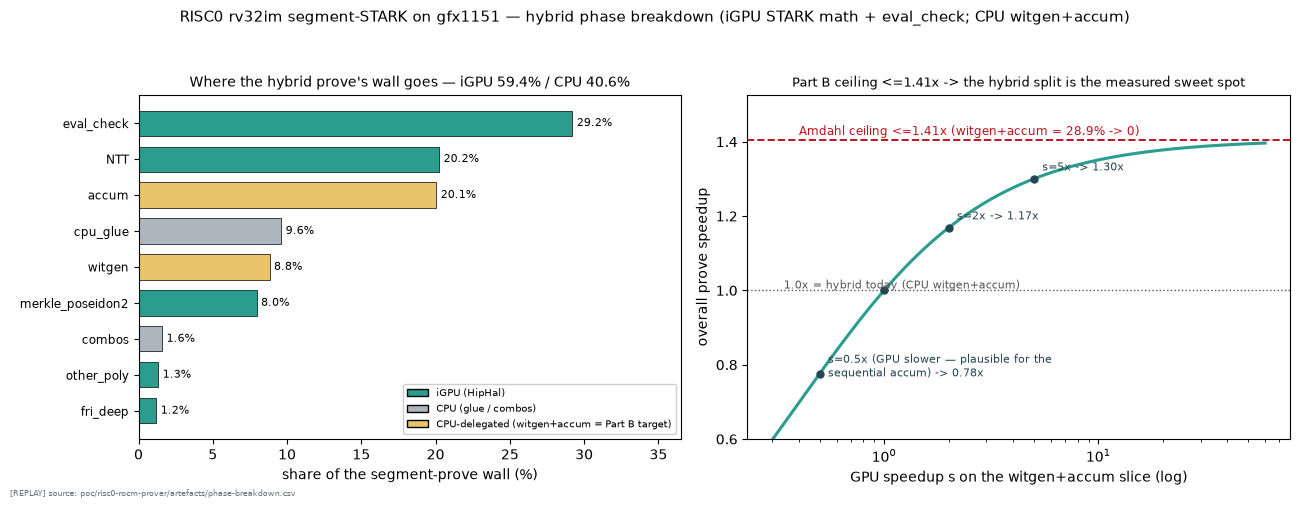

In [5]:
phases = lk.load_risc0_rocm_phases()
fig = lk.plot_risc0_rocm_phases(phases)

am = lk.risc0_rocm_amdahl(phases)
print(f"iGPU {am['gpu_busy_pct']:.1f}% / CPU {am['cpu_pct']:.1f}% of the prove (rocprofv3 cross-checked).")
print(f"witgen + accum (CPU-delegated) = {am['witgen_accum_pct']:.2f}%  "
      f"->  Amdahl ceiling <= {am['ceiling']:.2f}x if moved to the GPU.")
print("realistic envelope (overall speedup if witgen+accum ran on GPU at speedup s on that slice):")
for s in (0.5, 1.0, 2.0, 5.0):
    tail = "   (GPU slower: accum is a sequential grand-product -> a SLOWDOWN)" if s < 1 else ""
    print(f"  s={s:>4}x  ->  {am['envelope'][s]:.2f}x overall{tail}")
print("  => the hybrid keeps witgen+accum on the CPU by design — the measured sweet spot.")

## Panel (e) · The honest scope box (the overclaim firewall — carry this verbatim)

This is the non-negotiable framing that must travel with every surface (deck, handout, talking-points). The scope is presented **as part of the wow**, not as a trailing caveat.

| | |
|---|---|
| **Headline** | RISC0 zkVM **segment**-STARK now produces a **stock-verifier-accepted** seal on `gfx1151` (hybrid, path-i). |
| ✅ **SAY** | a GPU-produced rv32im **segment**-STARK seal, accepted by the **stock** `cargo risczero verify`, **bit-for-bit == risc0's own CpuHal** (DualHal 15/15); the 26k-LOC `eval_check` compiles native HIP + is bit-for-bit GPU==CPU. **Hybrid**: STARK math + eval_check on the iGPU; **witgen + accum CPU-delegated** over unified memory. |
| 🚫 **NEVER** | "the iGPU proves the whole zkVM" · "pure-GPU prover" · "beats a 5090" · dropping the **stock `r0vm` (CPU-only) vs scoped v2.3.2 fork (hybrid)** distinction. |
| **Speed** | segment-STARK **5.46×** on one workload; recursion **3.3–5.2×** scoped; complete Groth16 receipt **0.973×** (accelerator regression at this circuit size, not witness-bound). Layer-specific, same-box results; **correctness is the hard guarantee.** |
| **Amdahl** | segment witgen + accum = **28.9%** → **≤1.41×** ceiling; Groth16 GPU prove math is ~8.9 s but CPU witness + orchestration dominates ~187 s total. |
| **Additional stages** | recursion (lift/join/succinct) and Groth16 MSM/NTT run on iGPU; recursion witness/prefix-products and Groth16 witness generation remain CPU; **stock `r0vm` remains CPU-only**. |

The cell below prints the same scope from `lk.risc0_rocm_scope()` (numbers computed live from the artefacts) — the single structured source the deck / handout / talking-points should mirror.

In [6]:
scope = lk.risc0_rocm_scope(bench, phases)

print("HEADLINE:\n  " + scope["headline"])
print("\nSAY (state flatly):")
for s in scope["say"]:
    print("  + " + s)
print("\nNEVER (the overclaim firewall):")
for s in scope["never"]:
    print("  x " + s)
print("\nSPEED:      " + scope["speed"])
print("AMDAHL:     " + scope["amdahl"])
print("SCOPED OUT: " + scope["scope_out"])

HEADLINE:
  RISC0 zkVM segment-STARK now produces a stock-verifier-accepted seal on gfx1151 (hybrid, path-i).

SAY (state flatly):
  + a GPU-produced rv32im SEGMENT-STARK seal, accepted by the STOCK `cargo risczero verify` (Receipt is valid!)
  + bit-for-bit == risc0's own CpuHal (DualHal 15/15); eval_check compiles native HIP + is bit-for-bit GPU==CPU
  + HYBRID: STARK math + eval_check, recursion eval/accum, and Groth16 MSM/NTT on the iGPU; segment witgen/accum, recursion witness/prefix-products, and Groth16 witness generation remain CPU-delegated

NEVER (the overclaim firewall):
  x the iGPU proves the whole zkVM / a pure-GPU prover
  x beats a 5090
  x drop the stock r0vm (CPU-only) vs scoped v2.3.2 fork (hybrid) distinction

SPEED:      5.46x on ONE ~4-segment poseidon2 Cartesi-step prove (flat ~5.3-5.5x; the old ~6.6-6.8x = 5.46x x a 1.25x local-vs-shipped codegen gap) — workload-specific; correctness is the hard guarantee.
AMDAHL:     witgen + accum = 28.9% of the prove -> Amdah

## Honesty boundary (the same rule as every lab notebook)

- **This is the _scoped v2.3.2 fork_, not stock `r0vm`.** The stock/upstream RISC0 `r0vm` STARK stays **CPU-only on AMD** (official GPU support is CUDA + Metal only). To reproduce you must build `r0vm --features rocm` from the pinned fork.
- **Correctness is the durable claim; speed is layer-specific.** The segment-STARK GPU seal is stock-verifier-accepted and bit-for-bit == CpuHal (DualHal 15/15); **5.46×** is workload-/poseidon2-/hybrid-specific. Recursion is 3.3–5.2× scoped. The complete Groth16 receipt is **0.973×**; W0 traced the cause to an accelerator regression at this circuit size (CPU gnark 5.764 s vs ROCm 11.102 s), not to witness generation.
- **It is hybrid, not a pure-GPU prover.** Segment-STARK math + `eval_check`, recursion eval/accum, and Groth16 MSM/NTT run on the iGPU. Segment witgen/accum, recursion witness/prefix-products, and Groth16 witness generation remain CPU-delegated.
- This overturns the M13 "A3 RED" moonshot verifiably on `gfx1151`; Lab 24 records the next engineering lesson: optimize the measured bottleneck, and publish negative results. Full evidence + replay: [`poc/risc0-rocm-prover/`](../poc/risc0-rocm-prover/README.md) + [`reading-notes/path-i-risc0-rocm-stark.md`](../reading-notes/path-i-risc0-rocm-stark.md).

This remains the frontier centerpiece; continue to Lab 24 for Groth16 bottleneck forensics and the concrete GPU-witness roadmap.